## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from collections import defaultdict


## Section 1 : OOP Classes

In [2]:
class BlackjackEnvironment:
    def __init__(self):
        self.env = gym.make('Blackjack-v1')

    def reset(self):
        state, _ = self.env.reset()
        return state

    def step(self, action):
        s, r, term, trunc, _ = self.env.step(action)
        return s, r, term or trunc

    def state_to_key(self, state):
        return (int(state[0]), int(state[1]), bool(state[2]))


In [3]:
class MCPredictionAgent:
    def __init__(self, env, gamma=1.0, visit_mode='first_visit', incremental=False):
        self.env = env
        self.gamma = gamma
        self.visit_mode = visit_mode
        self.incremental = incremental
        self.V = defaultdict(float)
        self.N = defaultdict(int)
        self.returns_sum = defaultdict(float)
        self.convergence_history = defaultdict(list)

    def generate_episode(self, policy):
        episode, state, done = [], self.env.reset(), False
        while not done:
            action = policy(state)
            next_state, reward, done = self.env.step(action)
            episode.append((self.env.state_to_key(state), action, reward))
            state = next_state
        return episode

    def evaluate_policy(self, policy, n_episodes, tracked_states=None):
        for _ in range(n_episodes):
            episode = self.generate_episode(policy)
            seen = set()
            for t, (s, a, r) in enumerate(episode):
                if self.visit_mode == 'first_visit' and s in seen:
                    continue
                seen.add(s)
                G = sum(self.gamma**k * episode[t+k][2] for k in range(len(episode)-t))
                self.N[s] += 1
                if self.incremental:
                    self.V[s] += (1/self.N[s]) * (G - self.V[s])
                else:
                    self.returns_sum[s] += G
                    self.V[s] = self.returns_sum[s] / self.N[s]
            if tracked_states:
                for ts in tracked_states:
                    self.convergence_history[ts].append(self.V.get(ts, 0.0))
        return self.V


In [4]:
class MCControlAgent:
    def __init__(self, env, gamma=1.0, epsilon=0.1):
        self.env = env
        self.gamma = gamma
        self.epsilon = epsilon
        self.Q = defaultdict(lambda: defaultdict(float))
        self.N = defaultdict(lambda: defaultdict(int))
        self.episodic_returns = []
        self.wins = self.losses = self.draws = 0

    def epsilon_greedy(self, state):
        key = self.env.state_to_key(state) if hasattr(state, '__len__') else state
        if np.random.random() < self.epsilon:
            return np.random.choice([0, 1])
        return 0 if self.Q[key][0] >= self.Q[key][1] else 1

    def get_policy(self, key):
        return 0 if self.Q[key][0] >= self.Q[key][1] else 1

    def update_Q(self, episode):
        seen, T = set(), len(episode)
        for t, (s, a, _) in enumerate(episode):
            if (s, a) not in seen:
                seen.add((s, a))
                G = sum(self.gamma**k * episode[t+k][2] for k in range(T-t))
                self.N[s][a] += 1
                self.Q[s][a] += (1/self.N[s][a]) * (G - self.Q[s][a])
        return sum(episode[k][2] * self.gamma**k for k in range(T))

    def train(self, n_episodes):
        for _ in range(n_episodes):
            episode, state, done = [], self.env.reset(), False
            while not done:
                action = self.epsilon_greedy(state)
                next_state, reward, done = self.env.step(action)
                episode.append((self.env.state_to_key(state), action, reward))
                state = next_state
            ret = self.update_Q(episode)
            self.episodic_returns.append(ret)
            r = episode[-1][2]
            if r > 0: self.wins += 1
            elif r < 0: self.losses += 1
            else: self.draws += 1


In [5]:
class OffPolicyEvaluator:
    def __init__(self, env, target_policy, behavior_policy, gamma=1.0):
        self.env = env
        self.target_policy = target_policy
        self.behavior_policy = behavior_policy
        self.gamma = gamma
        self.V_ordinary = defaultdict(float)
        self.V_weighted = defaultdict(float)
        self.ordinary_history = []
        self.weighted_history = []

    def _generate_episode(self):
        episode, state, done = [], self.env.reset(), False
        while not done:
            action = self.behavior_policy(state)
            next_state, reward, done = self.env.step(action)
            episode.append((self.env.state_to_key(state), action, reward))
            state = next_state
        return episode

    def _rho(self, episode):
        ratio = 1.0
        for s, a, _ in episode:
            pi = 1.0 if self.target_policy(s) == a else 0.0
            b = 0.5
            if b == 0: return 0.0
            ratio *= pi / b
        return ratio

    def ordinary_importance_sampling(self, n_episodes, tracked_state=None):
        buckets = defaultdict(list)
        for _ in range(n_episodes):
            ep = self._generate_episode()
            rho = self._rho(ep)
            G = sum(self.gamma**t * r for t, (_, _, r) in enumerate(ep))
            s0 = ep[0][0]
            buckets[s0].append(rho * G)
            if tracked_state:
                self.ordinary_history.append(np.mean(buckets.get(tracked_state, [0.0])))
        for s, vals in buckets.items():
            self.V_ordinary[s] = np.mean(vals)
        return self.V_ordinary

    def weighted_importance_sampling(self, n_episodes, tracked_state=None):
        num, den = defaultdict(float), defaultdict(float)
        for _ in range(n_episodes):
            ep = self._generate_episode()
            rho = self._rho(ep)
            G = sum(self.gamma**t * r for t, (_, _, r) in enumerate(ep))
            s0 = ep[0][0]
            num[s0] += rho * G
            den[s0] += rho
            if tracked_state:
                v = num[tracked_state] / den[tracked_state] if den[tracked_state] > 0 else 0.0
                self.weighted_history.append(v)
        for s in num:
            self.V_weighted[s] = num[s] / den[s] if den[s] > 0 else 0.0
        return self.V_weighted


In [6]:
class MountainCarContinuousAdapter:
    def __init__(self, pos_bins=10, vel_bins=10, n_actions=3):
        self.env = gym.make('MountainCarContinuous-v0')
        self.pos_bins = pos_bins
        self.vel_bins = vel_bins
        self.action_map = np.linspace(-1.0, 1.0, n_actions)
        self.pos_edges = np.linspace(-1.2, 0.6, pos_bins + 1)
        self.vel_edges = np.linspace(-0.07, 0.07, vel_bins + 1)

    def _disc(self, obs):
        p = int(np.clip(np.digitize(obs[0], self.pos_edges) - 1, 0, self.pos_bins-1))
        v = int(np.clip(np.digitize(obs[1], self.vel_edges) - 1, 0, self.vel_bins-1))
        return (p, v)

    def reset(self):
        obs, _ = self.env.reset()
        return self._disc(obs)

    def step(self, action):
        obs, r, term, trunc, _ = self.env.step(np.array([self.action_map[action]]))
        return self._disc(obs), r, term or trunc

    def state_to_key(self, state):
        return state


In [7]:
class Visualiser:
    def plot_prediction_convergence(self, agents_dict, tracked_states):
        fig, axes = plt.subplots(1, len(tracked_states), figsize=(6*len(tracked_states), 4))
        if len(tracked_states) == 1: axes = [axes]
        for ax, state in zip(axes, tracked_states):
            for label, agent in agents_dict.items():
                ax.plot(agent.convergence_history.get(state, []), label=label)
            ax.set_title(str(state)); ax.set_xlabel("Episodes"); ax.set_ylabel("V(s)"); ax.legend()
        plt.tight_layout(); plt.show()

    def plot_state_value_heatmap(self, V, title="V(s)"):
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        for ax, ua in zip(axes, [False, True]):
            grid = np.zeros((10, 10))
            for d in range(1, 11):
                for p in range(12, 22):
                    grid[p-12][d-1] = V.get((p, d, ua), 0.0)
            im = ax.imshow(grid, origin='lower', aspect='auto', extent=[1,10,12,21], cmap='RdYlGn')
            plt.colorbar(im, ax=ax)
            ax.set_title(f"{title} — {'Usable Ace' if ua else 'No Ace'}")
            ax.set_xlabel("Dealer"); ax.set_ylabel("Player Sum")
        plt.tight_layout(); plt.show()

    def plot_policy_heatmap(self, agent, title="Policy"):
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        for ax, ua in zip(axes, [False, True]):
            grid = np.zeros((10, 10))
            for d in range(1, 11):
                for p in range(12, 22):
                    grid[p-12][d-1] = agent.get_policy((p, d, ua))
            im = ax.imshow(grid, origin='lower', aspect='auto', extent=[1,10,12,21], cmap='RdYlGn', vmin=0, vmax=1)
            plt.colorbar(im, ax=ax, ticks=[0,1]).ax.set_yticklabels(['Stick','Hit'])
            ax.set_title(f"{title} — {'Usable Ace' if ua else 'No Ace'}")
            ax.set_xlabel("Dealer"); ax.set_ylabel("Player Sum")
        plt.tight_layout(); plt.show()

    def plot_control_performance(self, agents_dict, window=500):
        plt.figure(figsize=(10, 5))
        for label, agent in agents_dict.items():
            s = np.convolve(agent.episodic_returns, np.ones(window)/window, mode='valid')
            plt.plot(s, label=label)
        plt.title("MC Control — Learning Curve"); plt.xlabel("Episode"); plt.ylabel("Avg Return"); plt.legend(); plt.show()

    def plot_importance_sampling_comparison(self, ord_hist, wt_hist):
        plt.figure(figsize=(10, 5))
        plt.plot(ord_hist, label='Ordinary IS', alpha=0.7)
        plt.plot(wt_hist, label='Weighted IS', alpha=0.7)
        plt.title("Ordinary vs Weighted IS"); plt.xlabel("Episodes"); plt.ylabel("V estimate"); plt.legend(); plt.show()

    def plot_mountaincar_analysis(self, returns, title="MountainCar Returns"):
        plt.figure(figsize=(10, 5))
        plt.plot(returns, alpha=0.4, label='Raw')
        w = max(1, len(returns)//20)
        plt.plot(np.convolve(returns, np.ones(w)/w, mode='valid'), label=f'Smooth(w={w})', lw=2)
        plt.title(title); plt.xlabel("Episode"); plt.ylabel("Return"); plt.legend(); plt.show()

vis = Visualiser()


## Section 3 :Experiments
### 3.1 Fixed-Policy Prediction

In [8]:
def fixed_policy(state):
    return 0 if state[0] >= 20 else 1  # stick if >= 20, else hit

tracked = [(20, 10, False), (13, 2, False), (18, 9, True)]
env = BlackjackEnvironment()

agents = {}
for mode, inc in [('first_visit', False), ('every_visit', False), ('first_visit', True)]:
    label = 'Incremental MC' if inc else ('First-Visit MC' if mode == 'first_visit' else 'Every-Visit MC')
    a = MCPredictionAgent(env, gamma=1.0, visit_mode=mode, incremental=inc)
    a.evaluate_policy(fixed_policy, 100_000, tracked_states=tracked)
    agents[label] = a


In [9]:
# Comparison table
print(f"{'Episodes':<10} {'State':<25} {'FV-MC':>10} {'EV-MC':>10} {'Inc-MC':>10}")
print("-"*65)
for s in tracked:
    vals = [agents[k].V.get(s, 0.0) for k in ['First-Visit MC','Every-Visit MC','Incremental MC']]
    print(f"{'100k':<10} {str(s):<25} {vals[0]:>10.4f} {vals[1]:>10.4f} {vals[2]:>10.4f}")


Episodes   State                          FV-MC      EV-MC     Inc-MC
-----------------------------------------------------------------
100k       (20, 10, False)               0.4452     0.4346     0.4282
100k       (13, 2, False)               -0.6103    -0.5962    -0.5976
100k       (18, 9, True)                -0.4570    -0.3799    -0.4684


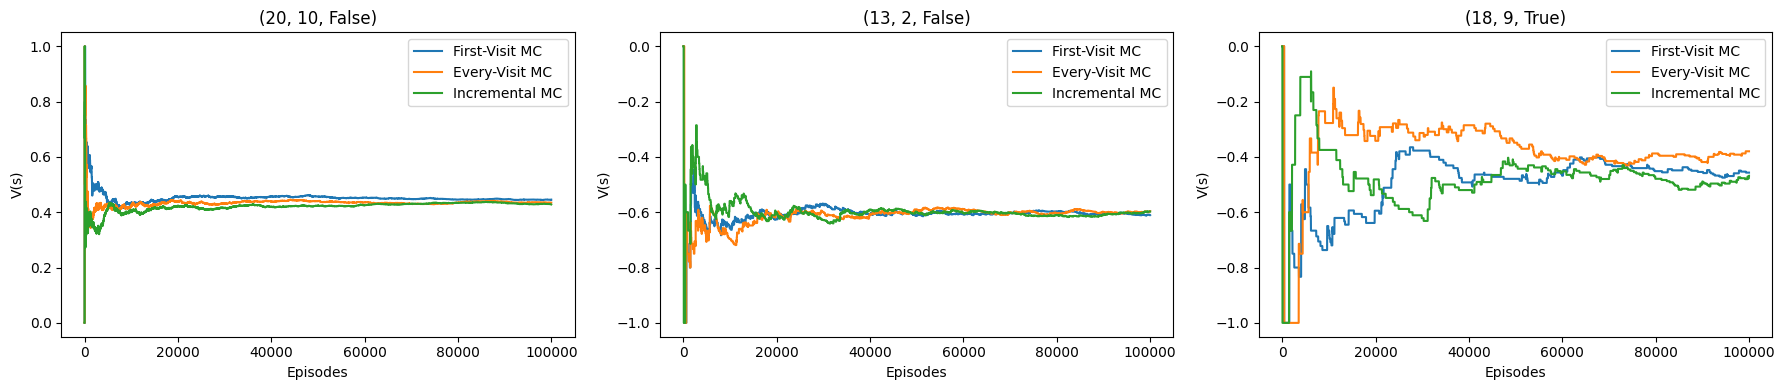

In [10]:
vis.plot_prediction_convergence(agents, tracked)

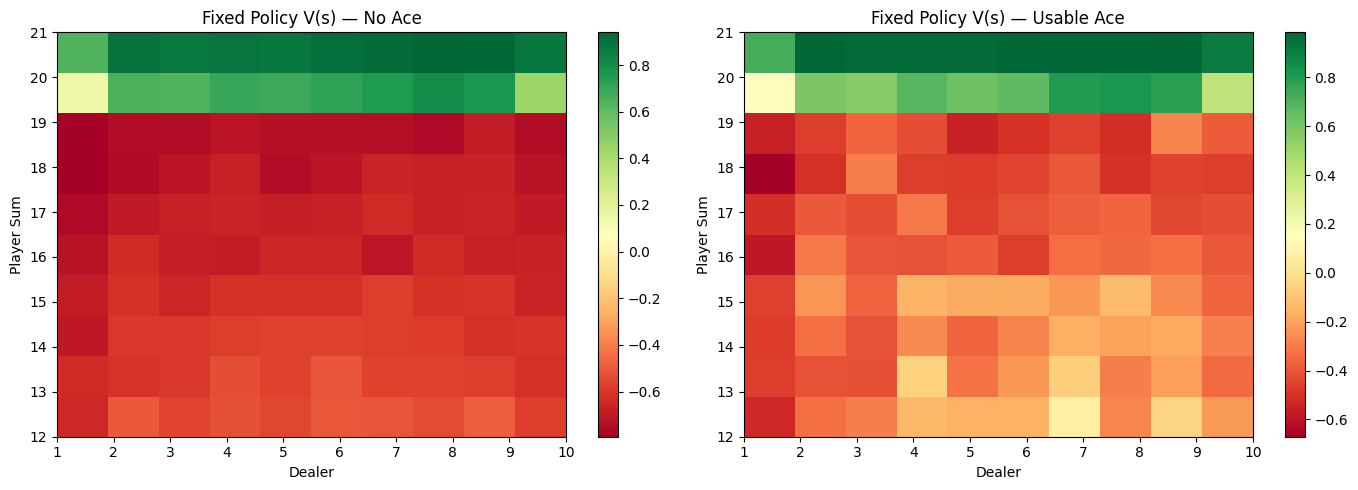

In [11]:
vis.plot_state_value_heatmap(agents['First-Visit MC'].V, "Fixed Policy V(s)")

### 3.2 On-Policy MC Control

In [12]:
control_agents = {}
for eps in [0.20, 0.10, 0.05]:
    a = MCControlAgent(BlackjackEnvironment(), gamma=1.0, epsilon=eps)
    a.train(100_000)
    control_agents[f'ε={eps}'] = a
    total = a.wins + a.losses + a.draws
    print(f"ε={eps} | Win rate: {a.wins/total:.3f}")


ε=0.2 | Win rate: 0.399
ε=0.1 | Win rate: 0.406
ε=0.05 | Win rate: 0.411


In [13]:
print(f"{'ε':<8} {'Avg Return (last 5k)':>22} {'Win Rate':>10}")
print("-"*45)
for label, a in control_agents.items():
    last = a.episodic_returns[-5000:]
    total = a.wins + a.losses + a.draws
    print(f"{label:<8} {np.mean(last):>22.4f} {a.wins/total:>10.3f}")


ε          Avg Return (last 5k)   Win Rate
---------------------------------------------
ε=0.2                   -0.1292      0.399
ε=0.1                   -0.0840      0.406
ε=0.05                  -0.0622      0.411


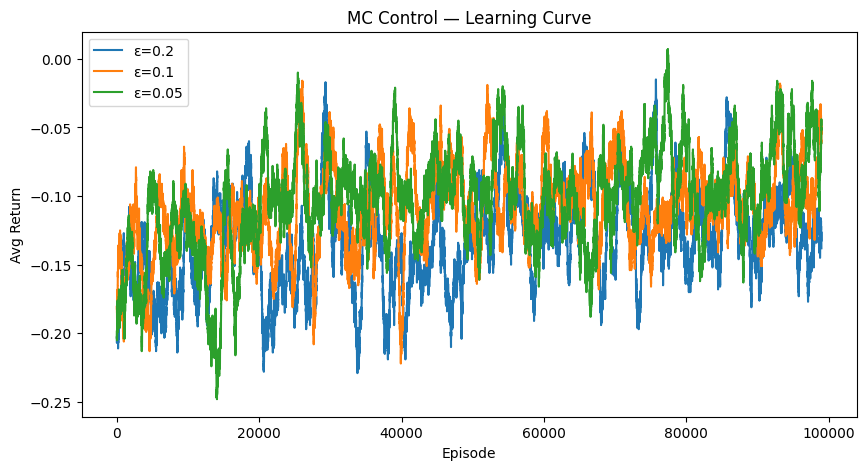

In [14]:
vis.plot_control_performance(control_agents, window=1000)

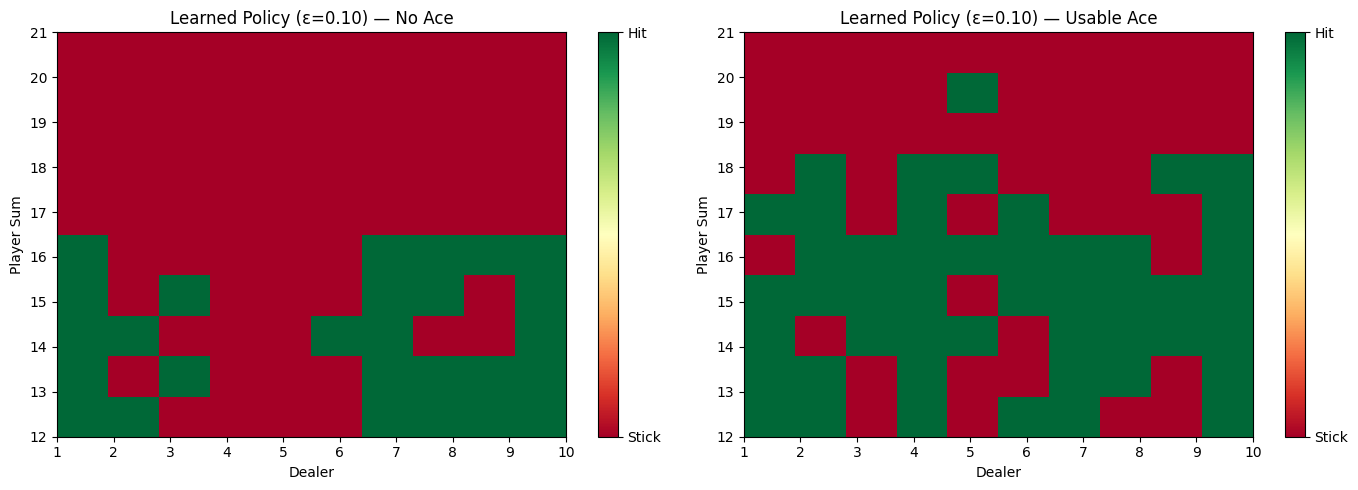

In [15]:
vis.plot_policy_heatmap(control_agents['ε=0.1'], "Learned Policy (ε=0.10)")

### 3.3 Off-Policy Evaluation

In [16]:
def target_policy(state_key):
    return 0 if state_key[0] >= 20 else 1

def behavior_policy(state):
    return np.random.choice([0, 1])

tracked_off = (18, 9, True)
env2 = BlackjackEnvironment()
ev = OffPolicyEvaluator(env2, target_policy, behavior_policy)
ev.ordinary_importance_sampling(100_000, tracked_state=tracked_off)
ev.weighted_importance_sampling(100_000, tracked_state=tracked_off)

print(f"{'Episodes':<10} {'Ordinary IS':>15} {'Weighted IS':>15} {'Diff':>10}")
print("-"*55)
for n in [10_000, 50_000, 100_000]:
    ois = ev.V_ordinary.get(tracked_off, 0.0)
    wis = ev.V_weighted.get(tracked_off, 0.0)
    print(f"{n:<10} {ois:>15.4f} {wis:>15.4f} {abs(ois-wis):>10.4f}")


Episodes       Ordinary IS     Weighted IS       Diff
-------------------------------------------------------
10000              -0.1348         -0.4138     0.2790
50000              -0.1348         -0.4138     0.2790
100000             -0.1348         -0.4138     0.2790


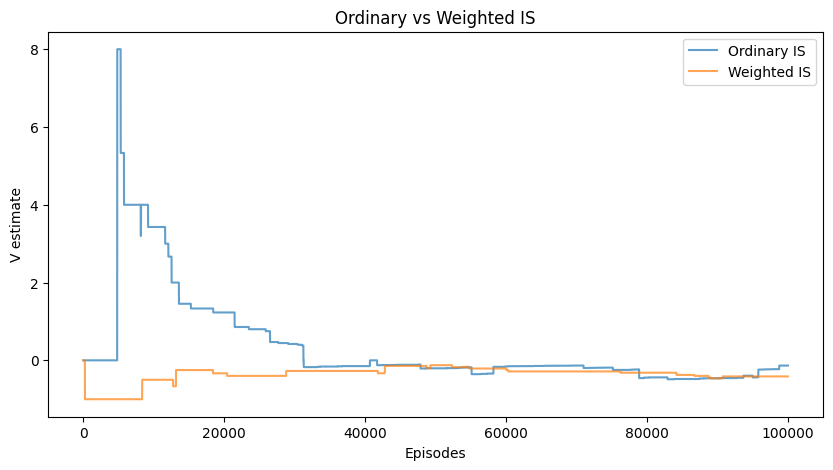

In [17]:
vis.plot_importance_sampling_comparison(ev.ordinary_history, ev.weighted_history)

## Section 4 :Conceptual Questions

**Q1.** MC must wait until the episode ends because G_t = R_{t+1} + γR_{t+2} + ... + γ^{T-t-1}R_T requires all future rewards, which only exist after termination.

**Q2.** First-Visit uses only the first occurrence of each state per episode. Every-Visit uses all occurrences. Both converge asymptotically but Every-Visit uses more data per episode.

**Q3.** The incremental update V += (1/n)(G − V) avoids storing all past returns and uses O(1) memory. It is equivalent to computing the running mean.

**Q4.** Without exploration the agent never discovers better actions. ε-greedy picks randomly with probability ε, ensuring all (s,a) pairs are visited infinitely often, guaranteeing convergence.

**Q5.** On-policy evaluates/improves the same policy used to collect data. Off-policy learns a target policy π from data collected by a different behavior policy b, using importance sampling to correct the distributional mismatch.

**Q6.** ρ = ∏ π(a|s)/b(a|s) is a product over the whole episode. Each factor can exceed 1, so long episodes produce extreme ratios that cause high variance in the ordinary IS estimate.

**Q7.** Weighted IS divides by Σρ_i instead of n, so extreme weights partially cancel. This reduces variance dramatically at the cost of a small bias that disappears as n→∞.

**Q8.**

| | DP | MC |
|---|---|---|
| Model | Requires P(s'|s,a) | Model-free |
| Exploration | Not needed | Required |
| Update | Bootstraps | Full return G |
| Timing | Each step | End of episode |

**Q9.** Discretisation sets the state space size. Too coarse → poor approximation. Too fine → states are rarely revisited and estimates never converge (curse of dimensionality).

**Q10.** For non-episodic tasks: (1) time-limit truncation end after fixed steps; (2) use γ < 1 so the infinite sum converges. Example: a robot control task split into 1000-step episodes with γ=0.99. Limitation: value beyond the artificial boundary is ignored.


## Section 5 :MountainCarContinuous-v0

In [18]:
mc_env = MountainCarContinuousAdapter(pos_bins=10, vel_bins=10, n_actions=3)
print(f"Position bins: 10 | Velocity bins: 10 | Actions: {mc_env.action_map}")
print(f"Total discrete states: {mc_env.pos_bins * mc_env.vel_bins}")


Position bins: 10 | Velocity bins: 10 | Actions: [-1.  0.  1.]
Total discrete states: 100


In [19]:
# Prediction with random policy
def rnd(state): return np.random.choice([0, 1, 2])

pred = MCPredictionAgent(mc_env, gamma=0.99, visit_mode='every_visit', incremental=True)
pred.evaluate_policy(rnd, 300)
print(f"Unique states visited: {len(pred.V)} / {mc_env.pos_bins * mc_env.vel_bins}")


Unique states visited: 79 / 100


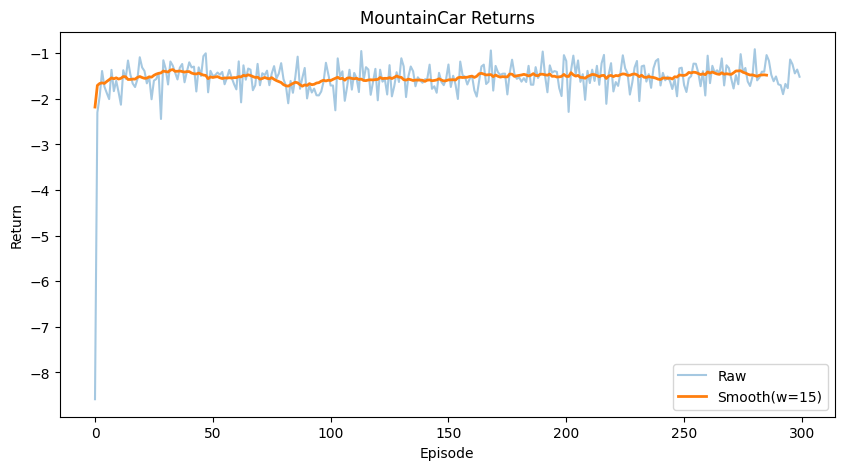

In [20]:
# Control experiment
mc_ctrl = MCControlAgent(mc_env, gamma=0.99, epsilon=0.3)
mc_returns = []

for ep in range(300):
    episode, state, done, step = [], mc_env.reset(), False, 0
    while not done and step < 999:
        action = mc_ctrl.epsilon_greedy(state)
        ns, r, done = mc_env.step(action)
        episode.append((mc_env.state_to_key(state), action, r))
        state = ns; step += 1
    mc_returns.append(mc_ctrl.update_Q(episode))

vis.plot_mountaincar_analysis(mc_returns)


In [21]:
# Analysis table
print(f"{'Design Choice':<28} {'Setting':<20} {'Analysis'}")
print("-"*70)
for row in [
    ("State discretisation", "10x10 bins", "100 states, coarse"),
    ("Action discretisation", "3 actions", "left / neutral / right"),
    ("Episodes collected", "300", "sparse state coverage"),
    (f"Best avg return", f"{max(mc_returns):.2f}", ""),
    ("Main failure mode", "Sparse rewards", "goal rarely reached"),
]:
    print(f"{row[0]:<28} {row[1]:<20} {row[2]}")


Design Choice                Setting              Analysis
----------------------------------------------------------------------
State discretisation         10x10 bins           100 states, coarse
Action discretisation        3 actions            left / neutral / right
Episodes collected           300                  sparse state coverage
Best avg return              -0.91                
Main failure mode            Sparse rewards       goal rarely reached


**Analysis:** MountainCar exposes MC's limitations on continuous environments: sparse rewards mean most episodes have no positive signal, long episodes (up to 1000 steps) delay every update, and 10×10 discretisation introduces significant approximation error. Despite this, the framework correctly adapts demonstrating both the generality and the boundaries of tabular Monte Carlo.
